# LAB 5: AVPR
Óscar Cubeles Ollé

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

import os
import ast
import copy
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision import transforms, datasets, models
from matplotlib.patches import Patch


# Table of Contents

**[Task 1: Hyperparameter Exploration](#task-1-hyperparameter-exploration)**
- [Experiment 1: Learning Rate Exploration](#experiment-1-learning-rate-exploration)
- [Experiment 2: Batch Size Exploration](#experiment-2-batch-size-exploration)
- [Experiment 3: Epochs Impact](#experiment-3-epochs-impact)

**[Task 2: Architectural Adaptation](#task-2-architectural-adaptation)**
- [Experiments Code](#experiments-code)
- [Results Analysis](#analyze-results)

**[Task 3: Data Transformation Techniques](#task-3-data-transformation-techniques)**
- [Data Transformation Code](#data-transformation-code)
- [Results Analysis](#results-analysis)
---

## Task 1: Hyperparameter Exploration 

### Default Provided Resnet

In [8]:
class CustomResNet(nn.Module):
    def __init__(self):
        super(CustomResNet, self).__init__()
        self.resnet = torchvision.models.resnet18(pretrained=True)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.resnet.fc = nn.Linear(512, 10)  # Assuming 10 classes for classification
    
    def forward(self, x): 
        return self.resnet(x)

### Data preparation
Download MNIST Dataset and use torch Dataloader

In [14]:
# Prepare the data 
transform = transforms.Compose([ 
    transforms.Resize((28, 28)), 
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,)) 
]) 

train_data = datasets.MNIST(root='./data', train=True, download=True, 
transform=transform) 
test_data = datasets.MNIST(root='./data', train=False, download=True, 
transform=transform) 
 
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, 
shuffle=True) 
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, 
shuffle=False)

100%|██████████| 9.91M/9.91M [00:18<00:00, 533kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 250kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.26MB/s]


### Training the ResNet

In [9]:
# Instantiate the custom ResNet model 
model = CustomResNet() 

# Define Loss Function & Optimizer 
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training Loop 
num_epochs = 5 

for epoch in range(num_epochs): 
    running_loss = 0.0 
    for i, data in tqdm(enumerate(train_loader, 0)): 
        inputs, labels = data 
        optimizer.zero_grad() 

        outputs = model(inputs) 
        loss = criterion(outputs, labels) 
        loss.backward() 
        optimizer.step() 

        running_loss += loss.item() 
        if i % 100 == 99: 
            print(f'Epoch [{epoch + 1}/{num_epochs}], ' 
                f'Step [{i + 1}/{len(train_loader)}], ' 
                f'Loss: {running_loss / 100:.4f}') 
            running_loss = 0.0 

100it [00:25,  4.38it/s]

Epoch [1/5], Step [100/938], Loss: 0.5197


200it [00:50,  3.91it/s]

Epoch [1/5], Step [200/938], Loss: 0.2075


300it [01:17,  3.61it/s]

...

800it [03:53,  3.57it/s]

Epoch [5/5], Step [800/938], Loss: 0.0442


900it [04:25,  3.03it/s]

Epoch [5/5], Step [900/938], Loss: 0.0347


938it [04:37,  3.37it/s]
938it [04:37,  3.37it/s]


### Testing the Trained ResNet 

In [6]:
# Testing the Model 
correct = 0 
total = 0 
with torch.no_grad(): 
    for data in test_loader: 
        inputs, labels = data 
        outputs = model(inputs) 
        _, predicted = torch.max(outputs.data, 1) 
        total += labels.size(0) 
        correct += (predicted == labels).sum().item() 
 
print(f'Accuracy on the test set: {(100 * correct / total):.2f}%')

Accuracy on the test set: 98.88%


In [7]:
# Save model checkpoint after all epochs 
save_path = 'model_checkpoint.pth'  # Path to save model checkpoints 
torch.save({ 
    'epoch': epoch, 
    'model_state_dict': model.state_dict(), 
    'optimizer_state_dict': optimizer.state_dict(), 
    'loss': loss 
}, save_path)

In [10]:
# Function to train model with different hyperparameters
def train_model_experiment(model, train_loader, test_loader, lr=0.001, num_epochs=5, experiment_name=""):
    """Train model and return training history"""
    model_copy = copy.deepcopy(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_copy.parameters(), lr=lr)
    
    train_losses = []
    train_accuracies = []
    epoch_times = []
    
    print(f"\n=== {experiment_name} ===")
    print(f"Learning Rate: {lr}, Epochs: {num_epochs}, Batch Size: {train_loader.batch_size}")
    
    for epoch in range(num_epochs):
        start_time = time.time()
        model_copy.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model_copy(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct_train / total_train
        epoch_time = time.time() - start_time
        
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        epoch_times.append(epoch_time)
        
        print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Time: {epoch_time:.2f}s')
    
    # Test the model
    model_copy.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model_copy(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    final_test_accuracy = 100 * correct / total
    print(f'Final Test Accuracy: {final_test_accuracy:.2f}%')
    
    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'epoch_times': epoch_times,
        'final_test_accuracy': final_test_accuracy,
        'experiment_name': experiment_name,
        'lr': lr,
        'epochs': num_epochs,
        'batch_size': train_loader.batch_size
    }


### Experiment 1: Learning Rate Exploration

In [3]:
# Only run the experiment if the CSV with results does not exist
if not os.path.exists("lr_results.csv"):
    print("EXPERIMENT 1: Learning Rate Impact")
    print("=" * 50)

    learning_rates = [0.01, 0.001, 0.0001]
    lr_results = []

    for lr in learning_rates:
        result = train_model_experiment(
            model, train_loader, test_loader, 
            lr=lr, num_epochs=5,
            experiment_name=f"Learning Rate {lr}"
        )
        lr_results.append(result)

    # Save results
    df = pd.DataFrame(lr_results)
    df.to_csv("lr_results.csv", index=False)

### Experiment 2: Batch Size Exploration

In [4]:
# Only run the experiment if the CSV with results does not exist
if not os.path.exists("batch_results.csv"):    
    print("\nEXPERIMENT 2: Batch Size Exploration")
    print("=" * 50)

    batch_sizes = [32, 64, 128]
    batch_results = []

    for batch_size in batch_sizes:
        # Create new data loaders with different batch sizes
        train_loader_exp = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
        test_loader_exp = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)
        
        result = train_model_experiment(
            model, train_loader_exp, test_loader_exp,
            lr=0.001, num_epochs=5,
            experiment_name=f"Batch Size {batch_size}"
        )
        batch_results.append(result)

    df = pd.DataFrame(batch_results)
    df.to_csv("batch_results.csv", index=False)

### Experiment 3: Epochs Impact

In [5]:
# Only run the experiment if the CSV with results does not exist
if not os.path.exists("epoch_results.csv"):    
    print("\nEXPERIMENT 3: Number of Epochs Impact")
    print("=" * 50)

    epoch_counts = [3, 5, 10]
    epoch_results = []

    for epochs in epoch_counts:
        result = train_model_experiment(
            model, train_loader, test_loader,
            lr=0.001, num_epochs=epochs,
            experiment_name=f"Epochs {epochs}"
        )
        epoch_results.append(result)

    df = pd.DataFrame(epoch_results)
    df.to_csv("epoch_results.csv", index=False)

In [7]:
def load_results(csv_path):
    df = pd.read_csv(csv_path)

    results = []
    for _, row in df.iterrows():
        entry = {}

        for col, val in row.items():
            if isinstance(val, str) and (val.startswith("[") or val.startswith("{")):
                try:
                    entry[col] = ast.literal_eval(val)
                except:
                    entry[col] = val
            else:
                entry[col] = val

        results.append(entry)

    return results

# Load all experiments
lr_results = load_results("lr_results.csv")
batch_results = load_results("batch_results.csv")
epoch_results = load_results("epoch_results.csv")

print("Loaded results:")
print(f"- Learning rate results: {len(lr_results)} entries")
print(f"- Batch size results: {len(batch_results)} entries")
print(f"- Epoch results: {len(epoch_results)} entries")

Loaded results:
- Learning rate results: 3 entries
- Batch size results: 3 entries
- Epoch results: 3 entries


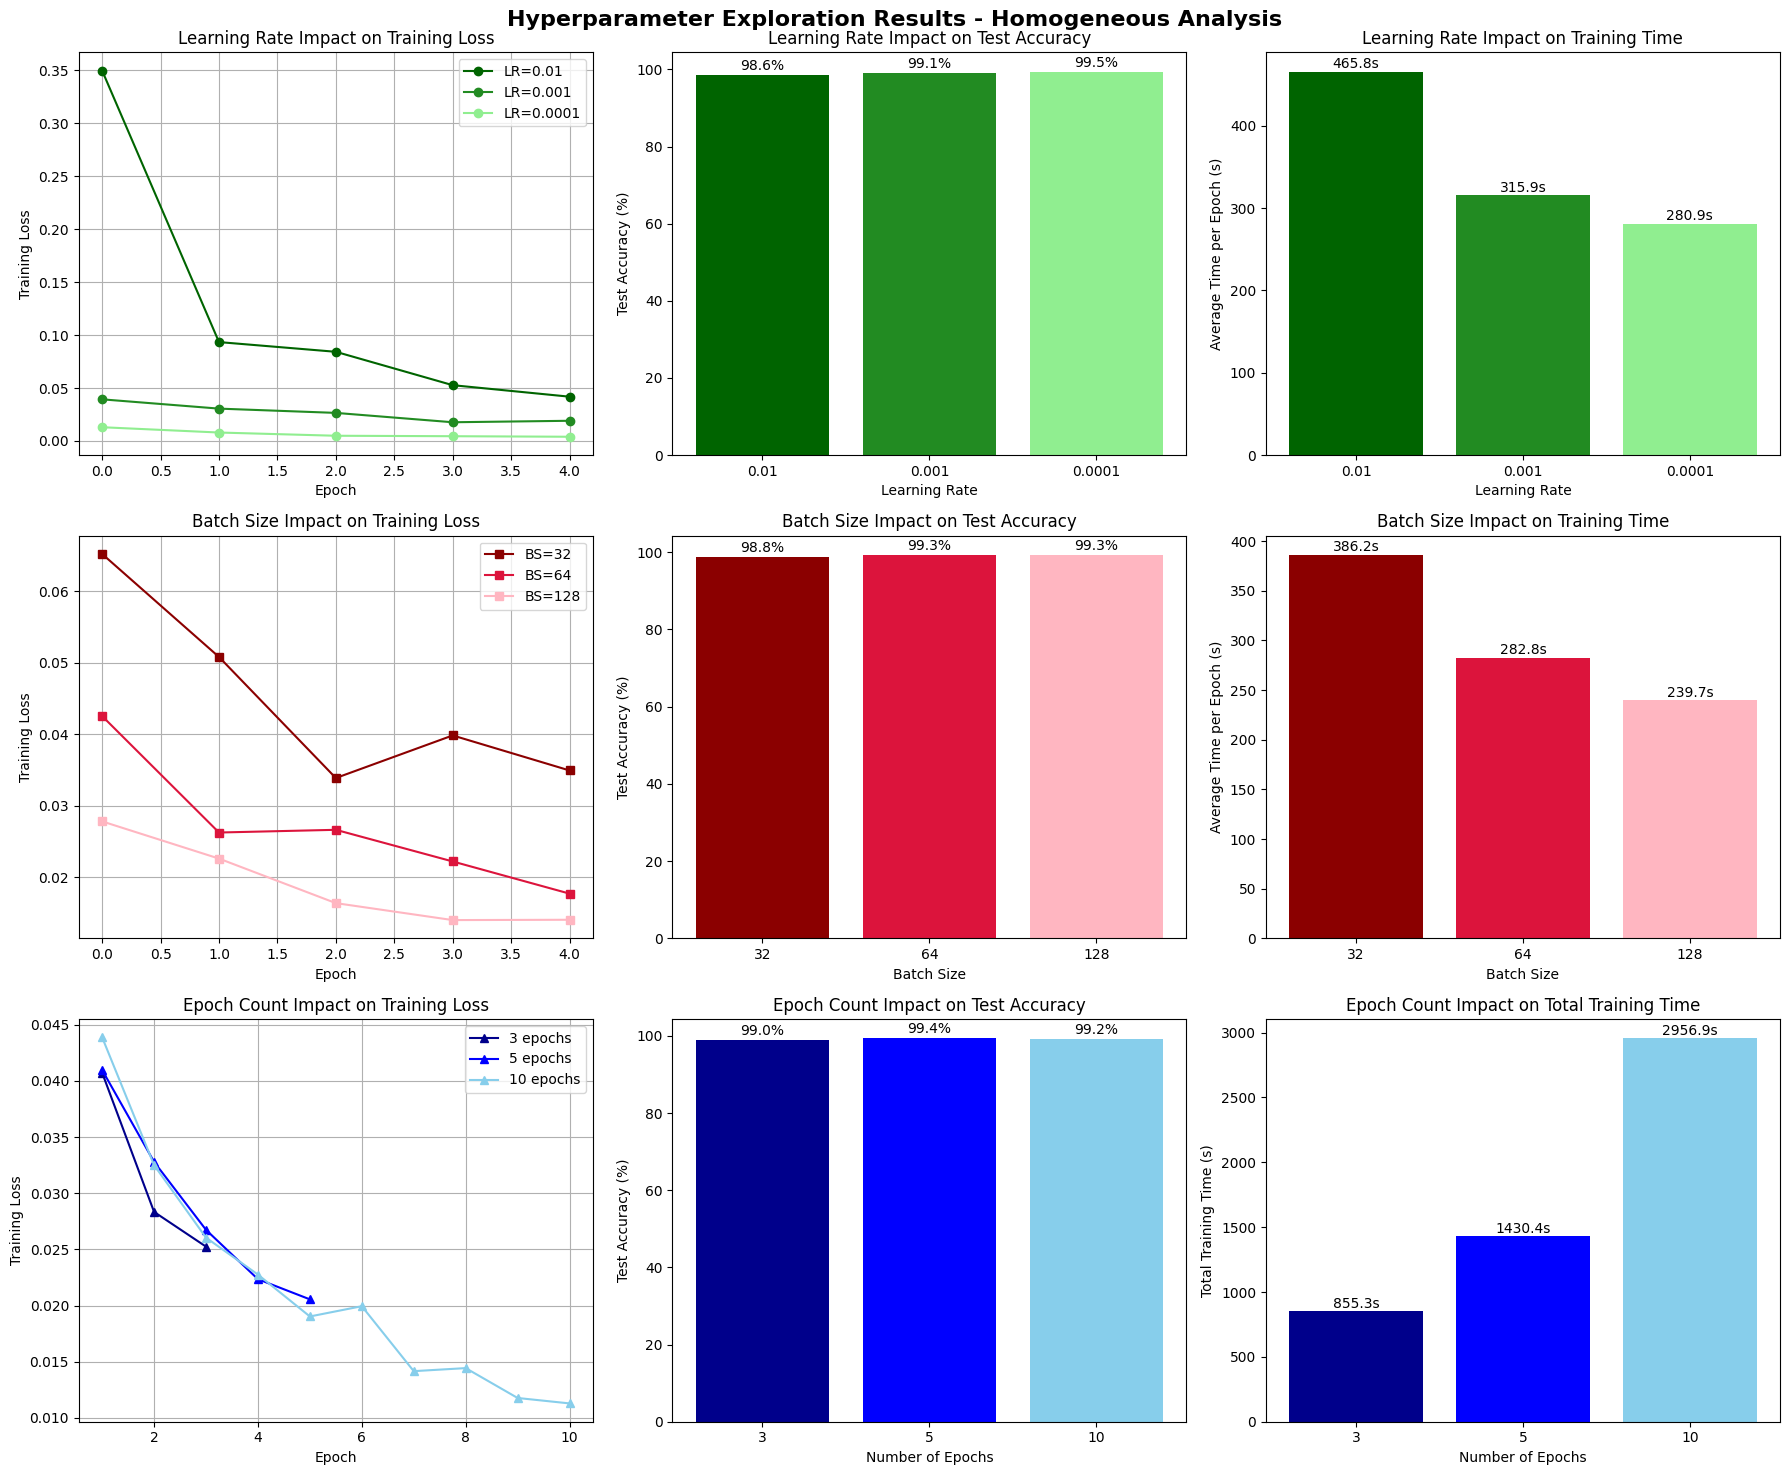

In [ ]:
# Create homogeneous plots - 3 rows (experiments) x 3 columns (metrics)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Hyperparameter Exploration Results - Homogeneous Analysis', fontsize=16, fontweight='bold')

# Define color families for each experiment type
lr_colors = ['#006400', '#228B22', '#90EE90']      # Dark green, green, light green
batch_colors = ['#8B0000', '#DC143C', '#FFB6C1']  # Dark red, red, light red  
epoch_colors = ['#00008B', '#0000FF', '#87CEEB']  # Dark blue, blue, light blue

# 1.1 Learning Rate Impact - Training Loss
axes[0, 0].set_title('Learning Rate Impact on Training Loss')
for i, result in enumerate(lr_results):
    axes[0, 0].plot(result['train_losses'], label=f'LR={result["lr"]}', marker='o', color=lr_colors[i])
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 1.2 Learning Rate Impact - Test Accuracy
axes[0, 1].set_title('Learning Rate Impact on Test Accuracy')
lr_values = [result['lr'] for result in lr_results]
lr_accuracies = [result['final_test_accuracy'] for result in lr_results]
bars1 = axes[0, 1].bar(range(len(lr_values)), lr_accuracies, color=lr_colors)
axes[0, 1].set_xlabel('Learning Rate')
axes[0, 1].set_ylabel('Test Accuracy (%)')
axes[0, 1].set_xticks(range(len(lr_values)))
axes[0, 1].set_xticklabels(lr_values)
for bar, acc in zip(bars1, lr_accuracies):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                   f'{acc:.1f}%', ha='center', va='bottom')

# 1.3 Learning Rate Impact - Training Time
axes[0, 2].set_title('Learning Rate Impact on Training Time')
lr_avg_times = [np.mean(result['epoch_times']) for result in lr_results]
bars1_time = axes[0, 2].bar(range(len(lr_values)), lr_avg_times, color=lr_colors)
axes[0, 2].set_xlabel('Learning Rate')
axes[0, 2].set_ylabel('Average Time per Epoch (s)')
axes[0, 2].set_xticks(range(len(lr_values)))
axes[0, 2].set_xticklabels(lr_values)
for bar, time_val in zip(bars1_time, lr_avg_times):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                   f'{time_val:.1f}s', ha='center', va='bottom')

# 2.1 Batch Size Impact - Training Loss
axes[1, 0].set_title('Batch Size Impact on Training Loss')
for i, result in enumerate(batch_results):
    axes[1, 0].plot(result['train_losses'], label=f'BS={result["batch_size"]}', marker='s', color=batch_colors[i])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 2.2 Batch Size Impact - Test Accuracy
axes[1, 1].set_title('Batch Size Impact on Test Accuracy')
batch_values = [result['batch_size'] for result in batch_results]
batch_accuracies = [result['final_test_accuracy'] for result in batch_results]
bars2 = axes[1, 1].bar(range(len(batch_values)), batch_accuracies, color=batch_colors)
axes[1, 1].set_xlabel('Batch Size')
axes[1, 1].set_ylabel('Test Accuracy (%)')
axes[1, 1].set_xticks(range(len(batch_values)))
axes[1, 1].set_xticklabels(batch_values)
for bar, acc in zip(bars2, batch_accuracies):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                   f'{acc:.1f}%', ha='center', va='bottom')

# 2.3 Batch Size Impact - Training Time
axes[1, 2].set_title('Batch Size Impact on Training Time')
batch_avg_times = [np.mean(result['epoch_times']) for result in batch_results]
bars2_time = axes[1, 2].bar(range(len(batch_values)), batch_avg_times, color=batch_colors)
axes[1, 2].set_xlabel('Batch Size')
axes[1, 2].set_ylabel('Average Time per Epoch (s)')
axes[1, 2].set_xticks(range(len(batch_values)))
axes[1, 2].set_xticklabels(batch_values)
for bar, time_val in zip(bars2_time, batch_avg_times):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                   f'{time_val:.1f}s', ha='center', va='bottom')

# 3.1 Epoch Count Impact - Training Loss
axes[2, 0].set_title('Epoch Count Impact on Training Loss')
for i, result in enumerate(epoch_results):
    epochs_range = range(1, len(result['train_losses']) + 1)
    axes[2, 0].plot(epochs_range, result['train_losses'], 
                   label=f'{result["epochs"]} epochs', marker='^', color=epoch_colors[i])
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Training Loss')
axes[2, 0].legend()
axes[2, 0].grid(True)

# 3.2 Epoch Count Impact - Test Accuracy
axes[2, 1].set_title('Epoch Count Impact on Test Accuracy')
epoch_values = [result['epochs'] for result in epoch_results]
epoch_accuracies = [result['final_test_accuracy'] for result in epoch_results]
bars3 = axes[2, 1].bar(range(len(epoch_values)), epoch_accuracies, color=epoch_colors)
axes[2, 1].set_xlabel('Number of Epochs')
axes[2, 1].set_ylabel('Test Accuracy (%)')
axes[2, 1].set_xticks(range(len(epoch_values)))
axes[2, 1].set_xticklabels(epoch_values)
for bar, acc in zip(bars3, epoch_accuracies):
    axes[2, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                   f'{acc:.1f}%', ha='center', va='bottom')

# 3.3 Epoch Count Impact - Training Time
axes[2, 2].set_title('Epoch Count Impact on Total Training Time')
epoch_total_times = [sum(result['epoch_times']) for result in epoch_results]
bars3_time = axes[2, 2].bar(range(len(epoch_values)), epoch_total_times, color=epoch_colors)
axes[2, 2].set_xlabel('Number of Epochs')
axes[2, 2].set_ylabel('Total Training Time (s)')
axes[2, 2].set_xticks(range(len(epoch_values)))
axes[2, 2].set_xticklabels(epoch_values)
for bar, time_val in zip(bars3_time, epoch_total_times):
    axes[2, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                   f'{time_val:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

If we look at the results, we can observe the following insights: 

- **Learning Rate Impact**: The higher the learning rate, the lower the training loss, which suggests that larger learning rates enable faster convergence during training by taking bigger optimization steps. However, regarding test accuracy, we see that there is no clear pattern as the highest (0.01) and smallest (0.0001) learning rates provide better accuracy than the balanced approach (0.001). This could indicate that the moderate learning rate (0.001) gets trapped in a suboptimal local minimum, while the high learning rate (0.01) can escape poor minima through larger jumps, and the very small learning rate (0.0001) finds a better solution through more careful exploration. As expected, the bigger the learning rate, the faster the training time per epoch is due to more aggressive parameter updates requiring fewer iterations to reach convergence.

- **Batch Size Impact**: Larger batch sizes exhibit behavior similar to smaller learning rates, producing higher training loss and longer training times per epoch. This occurs because larger batches provide more stable but less frequent gradient updates, requiring more computational work per iteration. However, unlike learning rate variations, batch size shows minimal impact on test accuracy, with all configurations achieving nearly identical performance (around 98%), suggesting that the model's final convergence quality is robust to batch size changes within this range.

- **Epoch Count Impact**: As expected, more epochs lead to lower training loss as the model has more iterations to minimize the loss function. However, this comes with the risk of overfitting if training continues too long without proper regularization. Test accuracy shows minimal variation across different epoch counts, suggesting that the model reaches near-optimal performance relatively quickly on this dataset. The linear relationship between epoch count and total training time is predictable, as doubling the epochs essentially doubles the computational cost while providing diminishing returns in accuracy improvement.

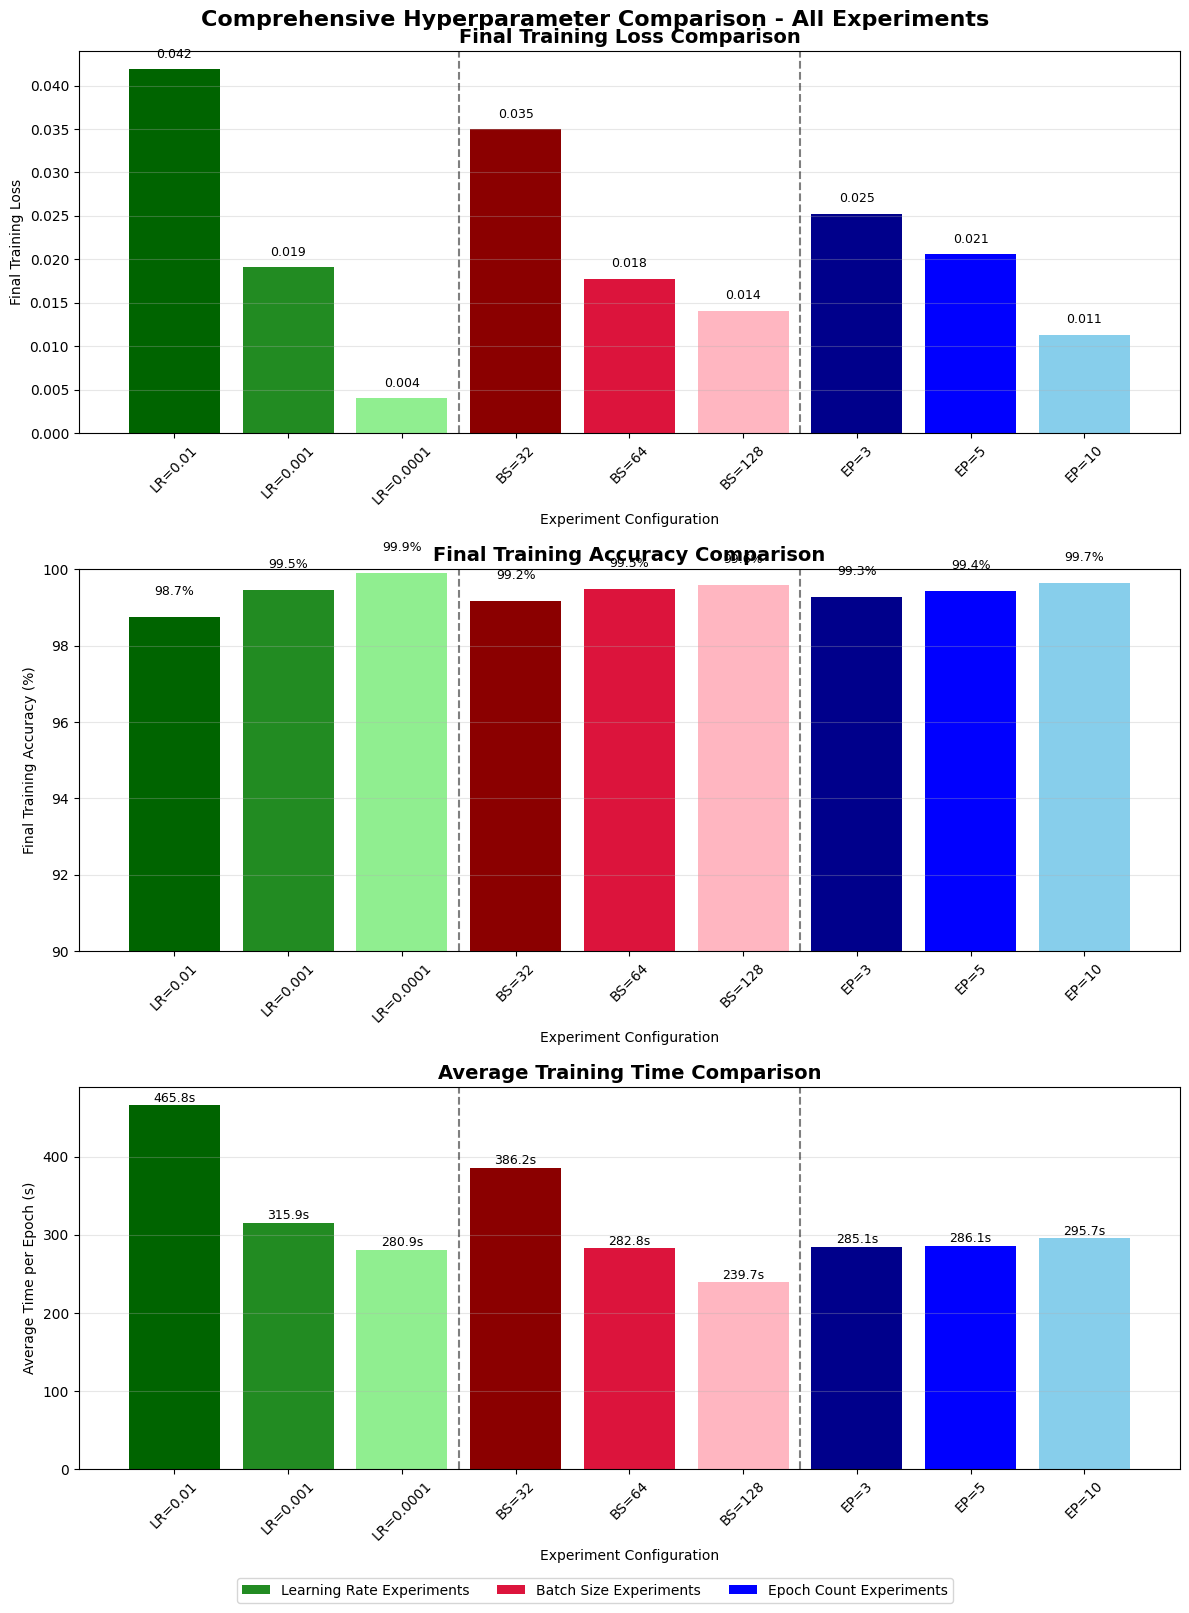

In [ ]:
# Create a transposed comparison plot - 3 rows x 1 column (metrics)
fig, axes = plt.subplots(3, 1, figsize=(12, 16))
fig.suptitle('Hyperparameter Comparison - All Experiments', fontsize=16, fontweight='bold')

# Define color families for each experiment type
lr_colors = ['#006400', '#228B22', '#90EE90']      # Dark green, green, light green
batch_colors = ['#8B0000', '#DC143C', '#FFB6C1']  # Dark red, red, light red  
epoch_colors = ['#00008B', '#0000FF', '#87CEEB']  # Dark blue, blue, light blue

# Prepare data for all experiments
all_experiment_names = []
all_train_losses = []
all_train_accuracies = []
all_train_times = []
all_colors = []

# Learning Rate experiments
for i, result in enumerate(lr_results):
    all_experiment_names.append(f'LR={result["lr"]}')
    all_train_losses.append(result['train_losses'][-1])  # Final training loss
    all_train_accuracies.append(result['train_accuracies'][-1])  # Final training accuracy
    all_train_times.append(np.mean(result['epoch_times']))  # Average time per epoch
    all_colors.append(lr_colors[i])

# Batch Size experiments  
for i, result in enumerate(batch_results):
    all_experiment_names.append(f'BS={result["batch_size"]}')
    all_train_losses.append(result['train_losses'][-1])
    all_train_accuracies.append(result['train_accuracies'][-1])
    all_train_times.append(np.mean(result['epoch_times']))
    all_colors.append(batch_colors[i])

# Epoch experiments
for i, result in enumerate(epoch_results):
    all_experiment_names.append(f'EP={result["epochs"]}')
    all_train_losses.append(result['train_losses'][-1])
    all_train_accuracies.append(result['train_accuracies'][-1])
    all_train_times.append(np.mean(result['epoch_times']))
    all_colors.append(epoch_colors[i])

# ========== PLOT 1: FINAL TRAINING LOSS ==========
bars1 = axes[0].bar(range(len(all_experiment_names)), all_train_losses, color=all_colors)
axes[0].set_title('Final Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Experiment Configuration')
axes[0].set_ylabel('Final Training Loss')
axes[0].set_xticks(range(len(all_experiment_names)))
axes[0].set_xticklabels(all_experiment_names, rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, loss in zip(bars1, all_train_losses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                f'{loss:.3f}', ha='center', va='bottom', fontsize=9)

# Add group separators
axes[0].axvline(x=2.5, color='black', linestyle='--', alpha=0.5)
axes[0].axvline(x=5.5, color='black', linestyle='--', alpha=0.5)

# ========== PLOT 2: FINAL TRAINING ACCURACY ==========
bars2 = axes[1].bar(range(len(all_experiment_names)), all_train_accuracies, color=all_colors)
axes[1].set_title('Final Training Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Experiment Configuration')
axes[1].set_ylabel('Final Training Accuracy (%)')
axes[1].set_xticks(range(len(all_experiment_names)))
axes[1].set_xticklabels(all_experiment_names, rotation=45)
axes[1].set_ylim(90, 100)  # Set y-axis range from 80% to 100%
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars2, all_train_accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

# Add group separators
axes[1].axvline(x=2.5, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(x=5.5, color='black', linestyle='--', alpha=0.5)

# ========== PLOT 3: AVERAGE TRAINING TIME ==========
bars3 = axes[2].bar(range(len(all_experiment_names)), all_train_times, color=all_colors)
axes[2].set_title('Average Training Time Comparison', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Experiment Configuration')
axes[2].set_ylabel('Average Time per Epoch (s)')
axes[2].set_xticks(range(len(all_experiment_names)))
axes[2].set_xticklabels(all_experiment_names, rotation=45)
axes[2].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, time_val in zip(bars3, all_train_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9)

# Add group separators
axes[2].axvline(x=2.5, color='black', linestyle='--', alpha=0.5)
axes[2].axvline(x=5.5, color='black', linestyle='--', alpha=0.5)

# Add legend
legend_elements = [
    Patch(facecolor='#228B22', label='Learning Rate Experiments'),
    Patch(facecolor='#DC143C', label='Batch Size Experiments'),
    Patch(facecolor='#0000FF', label='Epoch Count Experiments')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

plt.tight_layout()
plt.show()

1. **Training Loss Performance**: The smallest training loss was achieved by the lowest learning rate (0.0001), demonstrating precise convergence, while the highest learning rate (0.01) also performed competitively by escaping local minima through larger optimization steps.

2. **Accuracy Results**: The 0.0001 learning rate achieved the best performance, though all experiments exceeded 95% accuracy, demonstrating the ResNet architecture's robustness on MNIST. This consistent high performance across different hyperparameters indicates the model is well-suited for this classification task.

3. **Training Time Patterns**: Higher learning rates with smaller batch sizes require longer training durations per epoch due to increased gradient updates and the computational overhead of processing frequent, smaller batches outweighing the benefits of aggressive learning rate steps.

## Task 2: Architectural Adaptation

#### Experiments Code

In [11]:
# --- 1. Add Dropout to ResNet Block ---
def add_dropout(model, p=0.3, layer="layer1"):
    dropout = nn.Dropout(p)

    # Insert into the sequential layer
    original_layer = getattr(model.resnet, layer)

    new_layer = nn.Sequential(
        original_layer,
        dropout
    )
    setattr(model.resnet, layer, new_layer)
    return model


# --- 2. Change Kernel Size in First Conv Layer ---
def modify_conv_kernel(model, k=3):
    model.resnet.conv1 = nn.Conv2d(
        1, 64,
        kernel_size=k,
        stride=2,
        padding=k // 2,
        bias=False
    )
    return model


# --- 3. Modify Number of Filters in conv1 ---
def modify_conv_filters(model, new_filters=32):
    model.resnet.conv1 = nn.Conv2d(
        1, new_filters,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # Update subsequent layer expecting different input channels
    # ResNet18 expects next layer to receive 64 channels → update to match
    model.resnet.layer1[0].conv1 = nn.Conv2d(
        new_filters,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )
    return model


In [ ]:
def run_all_experiments(base_model, train_loader, test_loader, save_path="experiment_results.csv"):
    # If the file doesn't exist yet, create it with headers
    if not os.path.exists(save_path):
        pd.DataFrame(columns=["experiment_name", "accuracy", "loss", "other_metrics"]).to_csv(save_path, index=False)

    # 1. ===== LAYER MODIFICATION EXPERIMENTS =====
    layer_experiments = [
        ("Add Dropout after layer1", lambda m: add_dropout(m, p=0.3)),
        ("Add Dropout after layer2", lambda m: add_dropout(m, p=0.5, layer="layer2")),
    ]

    # 2. ===== FILTER / KERNEL SIZE MODIFICATIONS =====
    kernel_experiments = [
        ("Kernel Size 3x3", lambda m: modify_conv_kernel(m, k=3)),
        ("Kernel Size 5x5", lambda m: modify_conv_kernel(m, k=5)),
    ]

    all_experiments = layer_experiments + kernel_experiments 

    for name, modify_fn in all_experiments:

        model_variant = modify_fn(copy.deepcopy(base_model))

        result = train_model_experiment(
            model_variant,
            train_loader,
            test_loader,
            lr=0.001,
            num_epochs=5,
            experiment_name=name
        )

        # Append result immediately to CSV
        df = pd.DataFrame([result])
        df.to_csv(save_path, mode='a', header=False, index=False)
        print(f"Saved results for {name} to {save_path}")


In [17]:
if not os.path.exists("experiment_results.csv"):
    results = run_all_experiments(model, train_loader, test_loader)

In [ ]:
def run_depth_experiments(base_model, train_loader, test_loader, save_path="depth_experiments.csv"):
    # Create CSV with headers if it doesn't exist
    if not os.path.exists(save_path):
        pd.DataFrame(columns=["experiment_name", "status", "accuracy", "loss", "notes"]).to_csv(save_path, index=False)

    # ===== FEATURE MAP DEPTH EXPERIMENTS =====
    depth_experiments = [
        ("Half Filters (32)",  lambda m: modify_conv_filters(m, new_filters=32)),
        ("Double Filters (128)", lambda m: modify_conv_filters(m, new_filters=128)),
    ]

    for name, modify_fn in depth_experiments:

        try:
            model_variant = modify_fn(copy.deepcopy(base_model))

            # Try a forward pass with dummy input first → detect shape mismatches early
            model_variant.eval()
            dummy = torch.randn(1, 3, 224, 224)
            with torch.no_grad():
                _ = model_variant(dummy)

        except Exception as e:
            # Save the failure to CSV
            df = pd.DataFrame([{
                "experiment_name": name,
                "status": "FAILED",
                "accuracy": None,
                "loss": None,
                "notes": f"Model shape mismatch: {str(e)}"
            }])
            df.to_csv(save_path, mode='a', header=False, index=False)
            continue

        # If model is valid → train
        try:
            result = train_model_experiment(
                model_variant,
                train_loader,
                test_loader,
                lr=0.001,
                num_epochs=5,
                experiment_name=name
            )

            df = pd.DataFrame([{
                "experiment_name": name,
                "status": "SUCCESS",
                "accuracy": result.get("accuracy"),
                "loss": result.get("loss"),
                "notes": ""
            }])

            df.to_csv(save_path, mode='a', header=False, index=False)
            print(f"Saved results for {name} to {save_path}")

        except Exception as e:
            # Save training failure
            df = pd.DataFrame([{
                "experiment_name": name,
                "status": "FAILED DURING TRAIN",
                "accuracy": None,
                "loss": None,
                "notes": str(e)
            }])
            df.to_csv(save_path, mode='a', header=False, index=False)
            

In [19]:
if not os.path.exists("depth_experiments.csv"):
    results = run_depth_experiments(model, train_loader, test_loader)


In [38]:
# Load and visualize architectural adaptation experiment results
def load_and_plot_architectural_results(csv_path="experiment_results.csv"):
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Use the same parsing logic as load_results()
    results = []
    for _, row in df.iterrows():
        entry = {}
        for col, val in row.items():
            if isinstance(val, str) and (val.startswith("[") or val.startswith("{")):
                try:
                    entry[col] = ast.literal_eval(val)
                except:
                    entry[col] = val
            else:
                entry[col] = val
        results.append(entry)
    
    # Create  plots - 2 rows x 2 columns
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Architectural Adaptation Experiments - Analysis', fontsize=16, fontweight='bold')
    
    # Define colors for different experiment types
    dropout_colors = ['#FF6B6B', '#FF8E8E']  # Red tones for dropout experiments
    kernel_colors = ['#4ECDC4', '#45B7B8']   # Teal tones for kernel size experiments
    
    experiment_colors = []
    for result in results:
        if 'Dropout' in result['experiment_name']:
            if 'layer1' in result['experiment_name']:
                experiment_colors.append(dropout_colors[0])
            else:
                experiment_colors.append(dropout_colors[1])
        else:  # Kernel size experiments
            if '3x3' in result['experiment_name']:
                experiment_colors.append(kernel_colors[0])
            else:
                experiment_colors.append(kernel_colors[1])
    
    experiment_names = [result['experiment_name'] for result in results]
    
    # ========== PLOT 1: Training Loss Evolution ==========
    axes[0, 0].set_title('Training Loss Evolution', fontsize=14, fontweight='bold')
    for i, result in enumerate(results):
        epochs_range = range(1, len(result['train_losses']) + 1)
        axes[0, 0].plot(epochs_range, result['train_losses'], 
                       label=result['experiment_name'], marker='o', 
                       color=experiment_colors[i], linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Training Loss')
    #axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 0].grid(True, alpha=0.3)
    
    # ========== PLOT 2: Training Accuracy Evolution ==========
    axes[0, 1].set_title('Training Accuracy Evolution', fontsize=14, fontweight='bold')
    for i, result in enumerate(results):
        epochs_range = range(1, len(result['train_accuracies']) + 1)
        axes[0, 1].plot(epochs_range, result['train_accuracies'], 
                       label=result['experiment_name'], marker='s', 
                       color=experiment_colors[i], linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Training Accuracy (%)')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)
    
    # ========== PLOT 3: Final Test Accuracy Comparison ==========
    axes[1, 0].set_title('Final Test Accuracy Comparison', fontsize=14, fontweight='bold')
    final_accuracies = [result['final_test_accuracy'] for result in results]
    bars = axes[1, 0].bar(range(len(experiment_names)), final_accuracies, color=experiment_colors)
    axes[1, 0].set_xlabel('Experiment')
    axes[1, 0].set_ylabel('Test Accuracy (%)')
    axes[1, 0].set_xticks(range(len(experiment_names)))
    axes[1, 0].set_xticklabels([name.replace(' ', '\n') for name in experiment_names], 
                              rotation=0, ha='center', fontsize=10)
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, acc in zip(bars, final_accuracies):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                       f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # ========== PLOT 4: Average Training Time per Epoch ==========
    axes[1, 1].set_title('Average Training Time per Epoch', fontsize=14, fontweight='bold')
    avg_times = [np.mean(result['epoch_times']) for result in results]
    
    bars_time = axes[1, 1].bar(range(len(experiment_names)), avg_times, color=experiment_colors)
    axes[1, 1].set_xlabel('Experiment')
    axes[1, 1].set_ylabel('Average Time per Epoch (s)')
    axes[1, 1].set_xticks(range(len(experiment_names)))
    axes[1, 1].set_xticklabels([name.replace(' ', '\n') for name in experiment_names], 
                              rotation=0, ha='center', fontsize=10)
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, time_val in zip(bars_time, avg_times):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                       f'{time_val:.0f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return results


#### Analyze Results

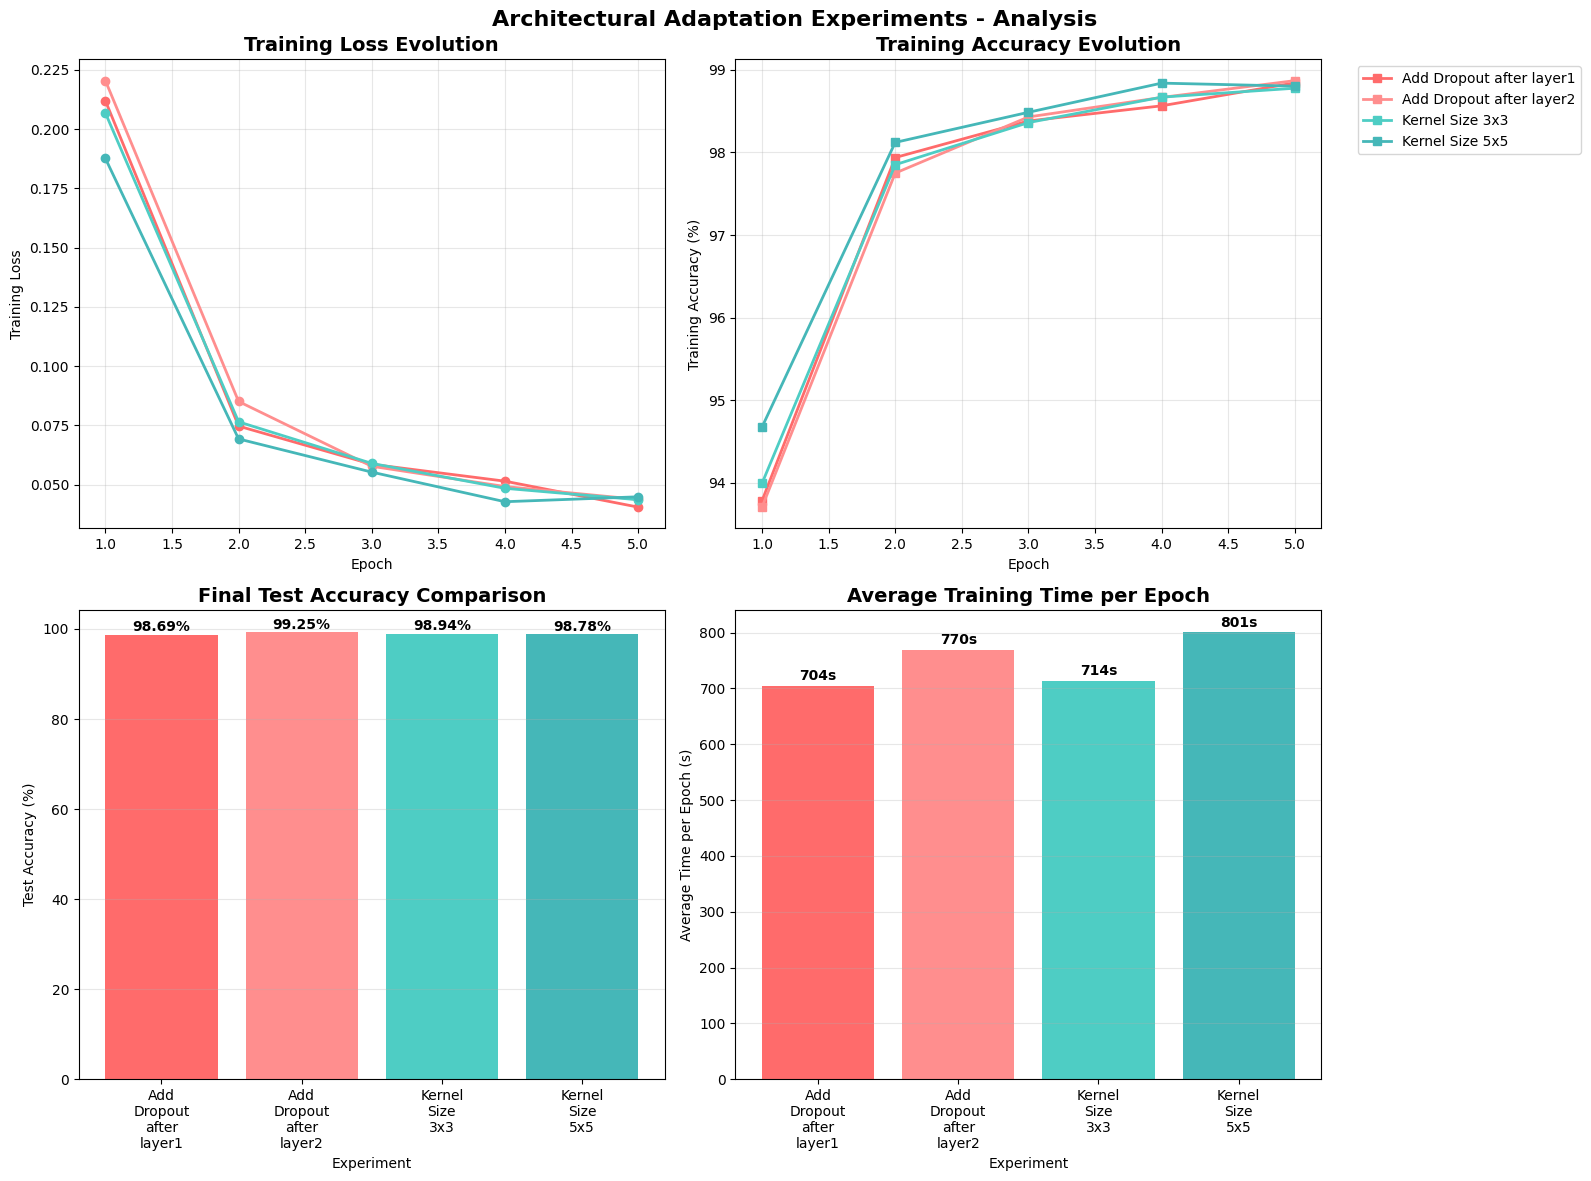

In [39]:
# Load and visualize the results for experiment 2
architectural_results = load_and_plot_architectural_results("experiment_results.csv")

The architectural modifications reveal insights about neural network design changes:

1. **Dropout Regularization**: Dropout in layer2 outperforms layer1 because deeper layers contain more task-specific features prone to overfitting, making regularization closer to decision layers more effective.

2. **Kernel Size Impact**: Larger kernels (5x5 vs 3x3) significantly increase computational cost with minimal accuracy gains, suggesting barely any return for this   classification.

3. **Filter Depth Trade-offs**: Halving filters (32) reduces capacity and cost but risks underfitting, while doubling (128) increases representation power at higher computational expense and potential overfitting risk.

It is important to note that training patterns across configurations indicate ResNet18 is already well-suited for MNIST, with architectural modifications made on the experiments having limited impact on learning capacity.


## Task 3: Data Transformation Techniques

#### Data Transformation Code

In [ ]:
# ===== Experiment Transformation Variants =====
experiment_transforms = [
    ("Resize+Normalize", transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])),

    ("Resize+RandomRotation", transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])),

    ("Resize+RandomAffine", transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])),

    ("Resize+RandomHorizontalFlip", transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])),

    ("Z-Score Normalization", transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
    ]))
]

# ===== Function to Run Transformation Experiments =====
def run_data_experiments(base_model, batch_size=64, num_epochs=5, save_path="data_experiments.csv"):
    results = []

    for name, transform_seq in experiment_transforms:
        print(f"\n\n==== Running Experiment: {name} ====")

        # Prepare datasets with the specific transform
        train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform_seq)
        test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform_seq)

        train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
        test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

        # Create a fresh copy of the base model for each experiment
        model_variant = copy.deepcopy(base_model)

        # Train and evaluate
        result = train_model_experiment(
            model_variant,
            train_loader,
            test_loader,
            lr=0.001,
            num_epochs=num_epochs,
            experiment_name=name
        )

        results.append(result)

        # Save results to CSV
        df = pd.DataFrame(results)
        df.to_csv(save_path, index=False)
        print(f"\nAll data experiments saved to: {save_path}")

    return results

# ===== Usage Example =====
base_model = CustomResNet()
results = run_data_experiments(base_model)

c:\Users\oscar\Documents\Oscar\Estudis\MAI\Q3\AVPR\LabsAVPR\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\oscar\Documents\Oscar\Estudis\MAI\Q3\AVPR\LabsAVPR\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)




==== Running Experiment: Resize+Normalize ====

=== Resize+Normalize ===
Learning Rate: 0.001, Epochs: 5, Batch Size: 64
Epoch [1/5] - Loss: 0.1827, Accuracy: 94.72%, Time: 1014.18s
Epoch [2/5] - Loss: 0.0728, Accuracy: 98.02%, Time: 1181.49s
Epoch [3/5] - Loss: 0.0514, Accuracy: 98.61%, Time: 379.84s
Epoch [4/5] - Loss: 0.0433, Accuracy: 98.75%, Time: 350.33s
Epoch [5/5] - Loss: 0.0372, Accuracy: 98.96%, Time: 346.90s
Final Test Accuracy: 98.95%

All data experiments saved to: data_experiments.csv


==== Running Experiment: Resize+RandomRotation ====

=== Resize+RandomRotation ===
Learning Rate: 0.001, Epochs: 5, Batch Size: 64
Epoch [1/5] - Loss: 0.2216, Accuracy: 93.61%, Time: 358.51s
Epoch [2/5] - Loss: 0.0874, Accuracy: 97.54%, Time: 364.80s
Epoch [3/5] - Loss: 0.0677, Accuracy: 98.07%, Time: 357.58s
Epoch [4/5] - Loss: 0.0656, Accuracy: 98.17%, Time: 356.30s
Epoch [5/5] - Loss: 0.0507, Accuracy: 98.60%, Time: 366.07s
Final Test Accuracy: 98.84%

All data experiments saved to: d

In [36]:
def load_and_plot_data_experiments(csv_path="data_experiments.csv"):
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Use the same parsing logic as load_results()
    results = []
    for _, row in df.iterrows():
        entry = {}
        for col, val in row.items():
            if isinstance(val, str) and (val.startswith("[") or val.startswith("{")):
                try:
                    entry[col] = ast.literal_eval(val)
                except:
                    entry[col] = val
            else:
                entry[col] = val
        results.append(entry)
    
    # Create plots - 2 rows x 2 columns
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Data Augmentation & Preprocessing Experiments - Analysis', fontsize=16, fontweight='bold')
    
    # Define colors for different experiment types
    experiment_colors = [
        '#2E8B57',  # Sea Green - Resize+Normalize (baseline)
        '#FF6347',  # Tomato - RandomRotation
        '#4682B4',  # Steel Blue - RandomAffine
        '#DAA520',  # Goldenrod - RandomHorizontalFlip
        '#9932CC'   # Dark Orchid - Z-Score Normalization
    ]
    
    experiment_names = [result['experiment_name'] for result in results]
    
    # ========== PLOT 1: Training Loss Evolution ==========
    axes[0, 0].set_title('Training Loss Evolution', fontsize=14, fontweight='bold')
    for i, result in enumerate(results):
        epochs_range = range(1, len(result['train_losses']) + 1)
        axes[0, 0].plot(epochs_range, result['train_losses'], 
                       label=result['experiment_name'], marker='o', 
                       color=experiment_colors[i], linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Training Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    # ========== PLOT 2: Training Accuracy Evolution ==========
    axes[0, 1].set_title('Training Accuracy Evolution', fontsize=14, fontweight='bold')
    for i, result in enumerate(results):
        epochs_range = range(1, len(result['train_accuracies']) + 1)
        axes[0, 1].plot(epochs_range, result['train_accuracies'], 
                       label=result['experiment_name'], marker='s', 
                       color=experiment_colors[i], linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Training Accuracy (%)')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(90, 100)  # Set y-axis range from 90% to 100%
    
    # ========== PLOT 3: Final Test Accuracy Comparison ==========
    axes[1, 0].set_title('Final Test Accuracy Comparison', fontsize=14, fontweight='bold')
    final_accuracies = [result['final_test_accuracy'] for result in results]
    bars = axes[1, 0].bar(range(len(experiment_names)), final_accuracies, color=experiment_colors)
    axes[1, 0].set_xlabel('Experiment')
    axes[1, 0].set_ylabel('Test Accuracy (%)')
    axes[1, 0].set_xticks(range(len(experiment_names)))
    axes[1, 0].set_xticklabels([name.replace('+', '+\n') for name in experiment_names], 
                              rotation=0, ha='center', fontsize=10)
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].set_ylim(98.5, 99.0)  # Focused range for better visibility
    
    # Add value labels on bars
    for bar, acc in zip(bars, final_accuracies):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # ========== PLOT 4: Average Training Time per Epoch ==========
    axes[1, 1].set_title('Average Training Time per Epoch', fontsize=14, fontweight='bold')
    avg_times = [np.mean(result['epoch_times']) for result in results]
    
    bars_time = axes[1, 1].bar(range(len(experiment_names)), avg_times, color=experiment_colors)
    axes[1, 1].set_xlabel('Experiment')
    axes[1, 1].set_ylabel('Average Time per Epoch (s)')
    axes[1, 1].set_xticks(range(len(experiment_names)))
    axes[1, 1].set_xticklabels([name.replace('+', '+\n') for name in experiment_names], 
                              rotation=0, ha='center', fontsize=10)
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, time_val in zip(bars_time, avg_times):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                       f'{time_val:.0f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return results


#### Results Analysis

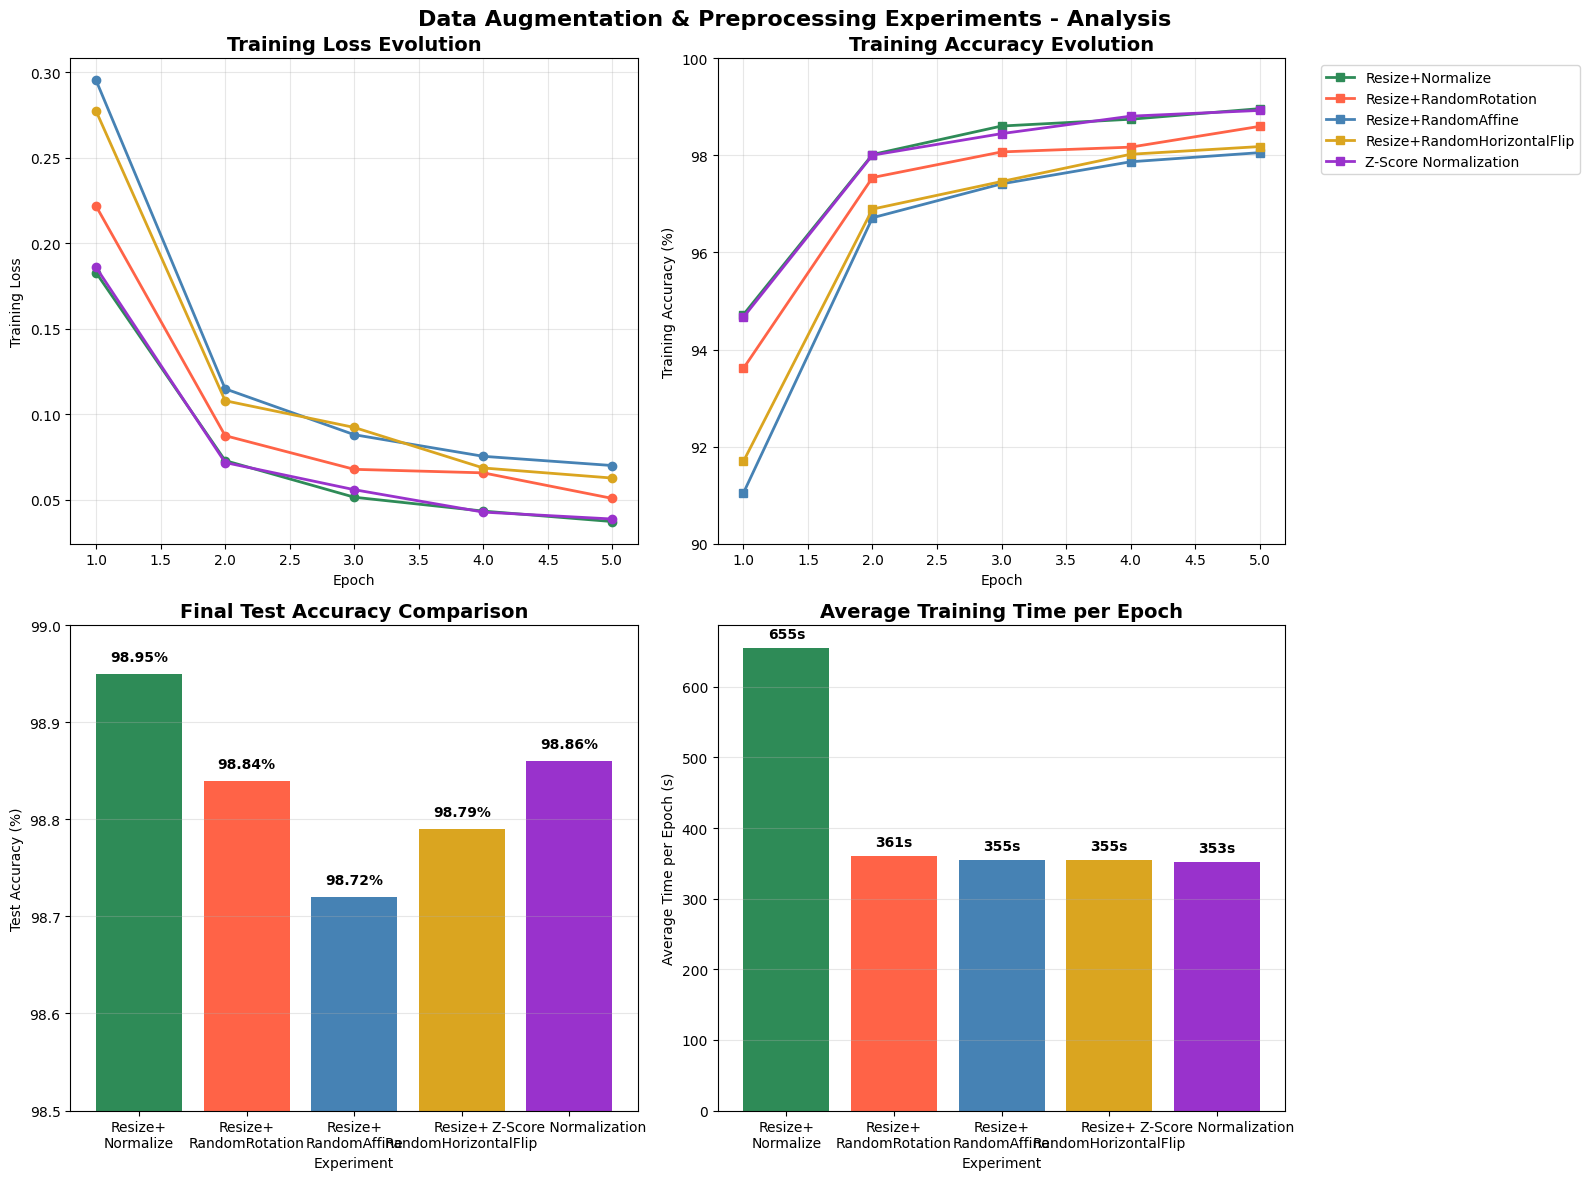

In [37]:
data_experiment_results = load_and_plot_data_experiments("data_experiments.csv")

**Test Accuracy Performance**: The baseline **Resize+Normalize** configuration achieves the highest test accuracy at **98.95%**, demonstrating that simple preprocessing can be highly effective. However, it comes at the cost of significantly longer training time (**655s** per epoch on average) compared to other augmentation techniques. The remaining configurations (Resize+RandomRotation, Resize+RandomAffine, Resize+RandomHorizontalFlip, and Z-Score Normalization) show remarkably consistent training times around **350-360s** per epoch, with stable test accuracies ranging from **98.72%** to **98.86%**.

**Training Accuracy**: Across all configurations, training accuracy shows a consistent pattern with a substantial improvement gap between epoch 1 and epoch 2, followed by steady convergence. Similarly, training loss decreases consistently across epochs for all preprocessing methods, demonstrating stable learning dynamics.

**Training Time Trade-offs**: While the baseline Resize+Normalize provides the best accuracy, data augmentation techniques (RandomRotation, RandomAffine, RandomHorizontalFlip) offer nearly comparable performance with approximately 45% reduction in training time, making them attractive options when computational efficiency is prioritized over marginal accuracy gains.

It is important to note that all the tests for this experiment were on the base Resnet model.